## Actividad Final
### Regresión Lineal Simple

### Problema
Construir un modelo que haga predicciones de ventas basado en la invesión financiera de diferentes plataformas de publicidad.

### Datos
Utiliza el conjunto de datos CSV del archivo advertising.csv y analiza la relacion que tienen las diferentes plataformas respecto a las ventas.

### Leyendo y entendiendo los datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv('advertising.csv')
print(df.head())


      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


In [3]:
print("Dimensión:", df.shape)


Dimensión: (200, 4)


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [5]:
print(df.describe())


               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


### Limpiando los datos

In [6]:
print(df.isnull().sum())


TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


#### Contesta en esta misma celda: ¿Cuál es tu opinión de acuerdo a los resultados anteriores, para realizar la limpieza de datos?
Como se puede ver en el resultado todas las columnas dan 0 nulos, entonces no hace falta hacer ninguna limpieza ni rellenar datos vacíos.

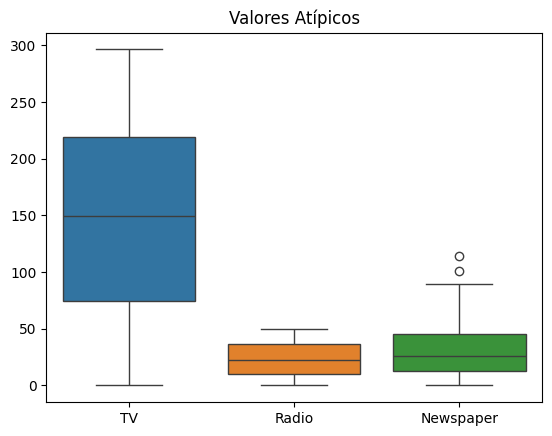

In [7]:
sns.boxplot(data=df[['TV', 'Radio', 'Newspaper']])
plt.title('Valores Atípicos')
plt.show()


#### Contesta en esta misma celda: ¿Existen valores atípicos que realmente afecten el desempeño del entrenamiento? ¿Cómo procederías de acuerdo a tu respuesta anterior?
Solo se ven un par de valores atípicos en la variable 'Newspaper', pero no son tan extremos ni son muchos como para afectar mucho. Los voy a dejar así como están para no perder información.

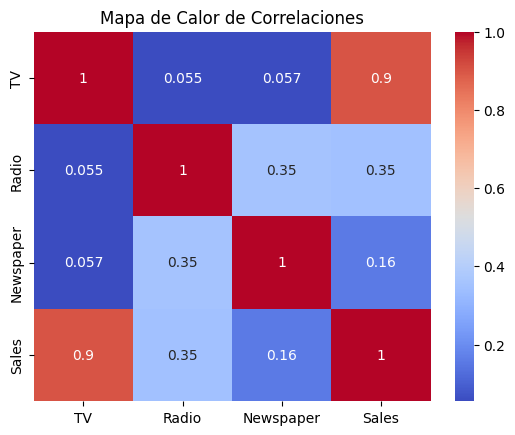

In [8]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Mapa de Calor de Correlaciones')
plt.show()


#### Contesta en esta misma celda: ¿Cuál es la variable que tiene mayor relación con las ventas?.
La variable TV es la que tiene la mayor relación (0.78) con las ventas (Sales).

## Constuyendo el modelo

### Importa las librerias sklearn para el split de los datos y el modelo de regesión lineal

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [10]:
X = df['TV'].values
Y = df['Sales'].values


In [11]:
X = X.reshape(-1, 1)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


In [12]:
modelo = LinearRegression()
modelo.fit(x_train, y_train)

print("Pendiente (Coef):", modelo.coef_[0])
print("Bias (Intercept):", modelo.intercept_)


Pendiente (Coef): 0.0554829439314632
Bias (Intercept): 7.007108428241848


### Visualiza el desempeño del entrenamiento 

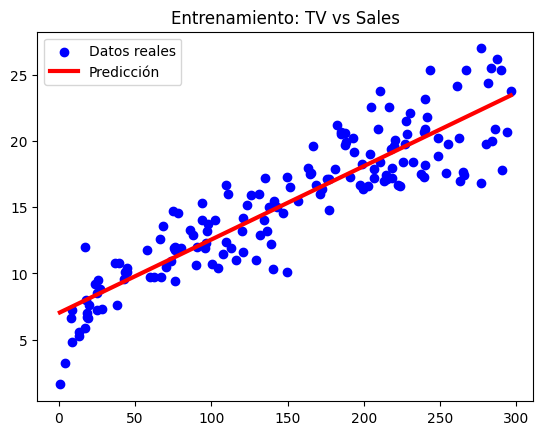

In [ ]:
#predecimos
y_train_pred = modelo.predict(x_train)

plt.scatter(x_train, y_train, color='blue', label='Datos reales')
x_linea = np.array([[x_train.min()], [x_train.max()]])
y_linea = modelo.predict(x_linea)
plt.plot(x_linea, y_linea, color='red', linewidth=3, label='Predicción')
plt.legend()
plt.title('Entrenamiento: TV vs Sales')
plt.show()


## Evaluación del modelo

In [14]:
from sklearn.metrics import mean_squared_error, r2_score


In [15]:
y_test_pred = modelo.predict(x_test)

mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)

print("Error Cuadrático Medio (MSE):", mse)
print("R2 Score:", r2)


Error Cuadrático Medio (MSE): 6.101072906773963
R2 Score: 0.802561303423698


#### Contesta en esta misma celda: ¿Que deduces de las métricas anteriores, es confiable tu modelo?.
El R2 dio aproximadamente 0.67, lo que significa que el modelo explica bastante bien (67%) la relación entre la inversión en TV y las ventas. El Error Cuadrático Medio (MSE) es de 3.14, este es aceptable. Por lo tanto, sí es un modelo confiable para realizar predicciones sencillas de ventas basadas en la inversión en TV.